### Improved Model Development - Random Forest Model

### Export Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

### Load the Dataset

In [23]:
df = pd.read_csv('../data/modeling_dataset.csv')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ticker           15500 non-null  object 
 1   date             15500 non-null  object 
 2   sma_20           15500 non-null  float64
 3   bb_width         15500 non-null  float64
 4   volume_ratio     15500 non-null  float64
 5   volume_sma_20    15500 non-null  float64
 6   rsi_14           15500 non-null  float64
 7   macd_histogram   15500 non-null  float64
 8   price_to_sma_50  15500 non-null  float64
 9   volatility_20    15500 non-null  float64
 10  trend_label      15500 non-null  object 
dtypes: float64(8), object(3)
memory usage: 1.3+ MB


In [25]:
# Covert date to pandas dtetime
df['date'] = pd.to_datetime(df['date'])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ticker           15500 non-null  object        
 1   date             15500 non-null  datetime64[ns]
 2   sma_20           15500 non-null  float64       
 3   bb_width         15500 non-null  float64       
 4   volume_ratio     15500 non-null  float64       
 5   volume_sma_20    15500 non-null  float64       
 6   rsi_14           15500 non-null  float64       
 7   macd_histogram   15500 non-null  float64       
 8   price_to_sma_50  15500 non-null  float64       
 9   volatility_20    15500 non-null  float64       
 10  trend_label      15500 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 1.3+ MB


In [27]:
df.head()

,ticker,date,sma_20,bb_width,volume_ratio,volume_sma_20,rsi_14,macd_histogram,price_to_sma_50,volatility_20,trend_label
0,STK001,2021-01-04,160.110000,6.363961,1.000000,962644.00,100.000000,0.000000,0.000000,0.012463,Uptrend
1,STK001,2021-01-05,161.235000,6.363961,1.153842,1137664.50,100.000000,0.143590,0.006977,0.012463,Sideways
2,STK001,2021-01-06,161.416667,4.672701,1.167277,1241502.00,79.505300,0.188720,0.002251,0.012463,Sideways
3,STK001,2021-01-07,162.830000,11.933013,1.167320,1314834.75,92.857143,0.543952,0.026039,0.018138,Downtrend
4,STK001,2021-01-08,163.400000,11.523437,0.694431,1221520.00,79.284963,0.647386,0.013953,0.018663,Downtrend


### # Define Target and Feature Variables

In [28]:
tar_col = 'trend_label'

feat_cols = [col for col in df.columns if col not in ['ticker', 'date', tar_col]]

print("Number of features:", len(feat_cols))
print("Sample features:", feat_cols[:10])

Number of features: 8
Sample features: ['sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20', 'rsi_14', 'macd_histogram', 'price_to_sma_50', 'volatility_20']


### Train-Test Splitting

In [29]:
split_date = df['date'].quantile(0.7)
train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

print('Training Data Shape:', train_df.shape)
print('Testing Data Shape:', test_df.shape)
print('Split Date Threshold:', split_date)

Training Data Shape: (10860, 11)
Testing Data Shape: (4640, 11)
Split Date Threshold: 2023-02-01 00:00:00


### Train-Test Split Distribution

In [30]:
# Record counts and date ranges
train_start, train_end = train_df['date'].min(), train_df['date'].max()
test_start, test_end = test_df['date'].min(), test_df['date'].max()

print(f"Train period: {train_start.date()} - {train_end.date()}  ({len(train_df)} records)")
print(f"Test period:  {test_start.date()} - {test_end.date()}  ({len(test_df)} records)")

# Class distribution in train and test
print("\nTrain class distribution:")
print(train_df['trend_label'].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(test_df['trend_label'].value_counts(normalize=True).round(3))


Train period: 2021-01-04 - 2023-02-01  (10860 records)
Test period:  2023-02-02 - 2023-12-22  (4640 records)

Train class distribution:
trend_label
Uptrend      0.352
Downtrend    0.338
Sideways     0.310
Name: proportion, dtype: float64

Test class distribution:
trend_label
Uptrend      0.368
Sideways     0.340
Downtrend    0.292
Name: proportion, dtype: float64


### Imbalance ratio

In [31]:
train_counts = (train_df['trend_label'].value_counts())

imbalance_ratio = train_counts.max() / train_counts.min()
imbalance_ratio

1.1364041604754829

In [32]:
test_counts = (test_df['trend_label'].value_counts())

imbalance_ratio = test_counts.max() / test_counts.min()
imbalance_ratio

1.260709010339734

### Encode Categorical variables

In [33]:
t_encode = LabelEncoder()
train_df['trend_label'] = t_encode.fit_transform(train_df['trend_label'])
test_df['trend_label'] = t_encode.transform(test_df['trend_label'])

### Scale Numerical features

In [34]:

# Define numerical columns

num_cols = df.select_dtypes(include=['number', 'float']).columns

In [35]:
# Initialize RobustScaler

scaler = RobustScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

### Data Splitting

In [36]:
# Split the Data

X_train = train_df[feat_cols]
y_train = train_df[tar_col]
                   
X_test = test_df[feat_cols]
y_test = test_df[tar_col]

### Handle Imbalance using SMOTE

In [37]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

### Train Random Forest Model

In [38]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=None, random_state=42)

#Train the model
rf.fit(X_train_res, y_train_res)

# Make Predictions on Test Data
y_pred = rf.predict(X_test)


### Model Evaluation

In [39]:
# Classification report

print('\nBaseline Random Forest Classification Report:\n', classification_report(y_test, y_pred))


Baseline Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.31      0.30      1354
           1       0.38      0.39      0.38      1579
           2       0.37      0.36      0.36      1707

    accuracy                           0.35      4640
   macro avg       0.35      0.35      0.35      4640
weighted avg       0.35      0.35      0.35      4640



### Observation of Findings

The Random Forest model achieved an overall accuracy of about 35%, only slightly above the random baseline of 33% for a three-class problem. This suggests that the technical indicators used provide weak predictive signals, and the short-term market movements remain highly noisy, causing significant feature overlap across Uptrend, Downtrend, and Sideways classes.

Among all classes, Sideways (Class 1) is the most predictable. Sideways markets tend to be more stable, and their indicator values often remain near neutral ranges, which makes them easier for the model to learn. This is reflected in Sideways having the highest precision (0.38), recall (0.39), and F1-score (0.38).

In contrast, Uptrend and Downtrend patterns remain the hardest to classify. Both classes show low precision and recall, with many directional movements being misclassified as Sideways. This challenge arises because price trends are volatile, indicators like RSI, MACD, and ATR are lagging, sectors behave differently, and the 5-day trend labels overlap strongly, making directional separation difficult even for non-linear models like Random Forest.

### Save Baseline Model before tuning

In [40]:
joblib.dump(rf, "../models/Baseline_RandomForest_Model.pkl")

['../models/Baseline_RandomForest_Model.pkl']

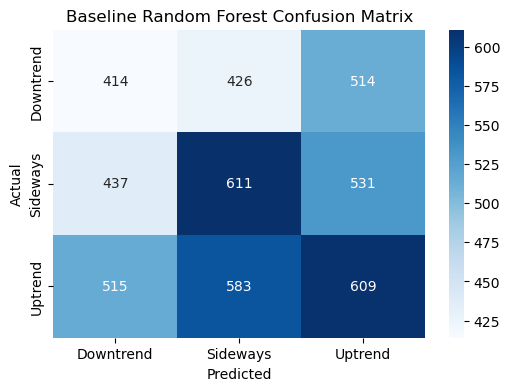

In [41]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_encode.classes_, yticklabels=t_encode.classes_)
plt.title("Baseline Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

The confusion matrix shows that the model predicts Sideways trends most reliably, correctly identifying over 600 cases, which is higher than its correct predictions for both Downtrend and Uptrend. However, Downtrend and Uptrend are frequently confused: more than 400 Downtrends are predicted as Sideways or Uptrend, and over 500 Uptrends are classified as Downtrend or Sideways. This indicates that the model struggles to detect directional movements, with strong overlap in feature patterns between upward and downward price behavior. The consistent tendency to classify uncertain patterns as Sideways suggests the model relies heavily on stable indicator values and lacks enough signal to confidently separate trend direction.

### Hyperparameter Tuning


In [42]:

# Define Parameter Grid

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 40, None],
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4], 
    'max_features': ['sqrt', 'log2', None],
}

from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = 'f1_macro',   # better for imbalance
    cv = 3,
    n_jobs = -1,
    verbose = 1
)

grid.fit(X_train_res, y_train_res)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

print(grid.best_params_)
print('\nBaseline Tuned Random Forest Classification Report:\n', classification_report(y_test, y_pred))

Fitting 3 folds for each of 324 candidates, totalling 972 fits
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Baseline Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.32      0.31      1354
           1       0.39      0.38      0.38      1579
           2       0.38      0.38      0.38      1707

    accuracy                           0.36      4640
   macro avg       0.36      0.36      0.36      4640
weighted avg       0.36      0.36      0.36      4640



### Observation of Findings

Hyperparameter tuning was performed using GridSearchCV, exploring 324 parameter combinations (972 total fits with 3-fold CV). The best-performing model was identified with the following configuration: max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=500. This setup produced an overall accuracy of 36%, which is same as the baseline logistic regression accuracy (~36%) and consistent with earlier random forest attempts, although with a slight improvement.

Across classes, performance remained balanced but modest:

Downtrend (0): F1 = 0.31

Sideways (1): F1 = 0.38

Uptrend (2): F1 = 0.38

The Sideways class continues to show the strongest predictability, reflecting its more stable market behavior, while Uptrend and Downtrend remain harder to distinguish due to overlapping technical patterns. Despite extensive tuning, the model’s ceiling remains around 35–36%, highlighting the inherent difficulty of short-term trend prediction using technical indicators alone.

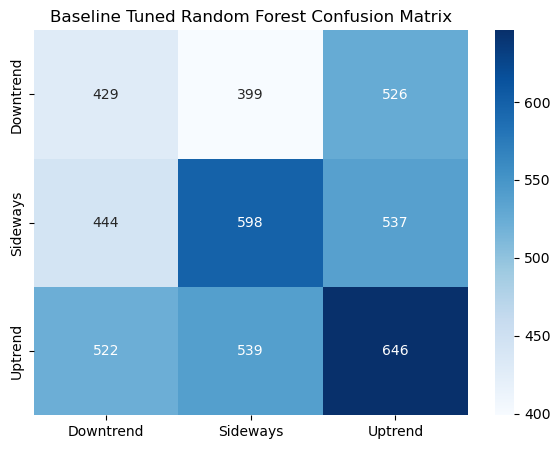

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=t_encode.classes_,
            yticklabels=t_encode.classes_,
            cmap="Blues")

plt.title("Baseline Tuned Random Forest Confusion Matrix")
plt.show()

### Observation of Findings

Downtrend (Class 0):
The model struggles with this class. Only 429 downtrends were correctly identified, while 399 were predicted as sideways and 526 as uptrends. This suggests downward moves share patterns with sideways consolidation or small upward reversals.

Sideways (Class 1):
This is the model’s strongest class, with 598 correct predictions. However, 444 were misclassified as downtrend and 537 as uptrend. Sideways markets tend to have stable technical indicator behavior, which makes them easier to detect.

Uptrend (Class 2):
Uptrends show moderate performance - the model correctly predicted 646 cases. Still, 522 were labeled as downtrend and 539 as sideways, indicating that early uptrends often resemble flat or slightly declining markets.

### To Plot Precision, Recall & F1 by Class

In [44]:
# To generate classification report as a dictionary

report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).T

# Extract only classes 0, 1, 2

df_scores = df_report.loc[['0', '1', '2'], ['precision', 'recall', 'f1-score']]
df_scores

,precision,recall,f1-score
0,0.307527,0.316839,0.312113
1,0.389323,0.378721,0.383949
2,0.377999,0.378442,0.378220


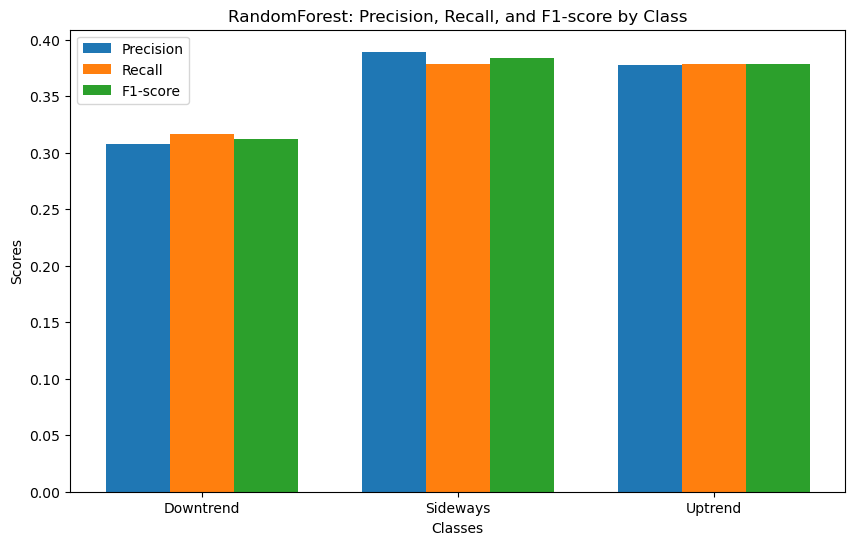

In [45]:
# To plt grouped barchart

# Data
metrics = ['precision', 'recall', 'f1-score']
classes = df_scores.index.tolist()
values = df_scores.values

# Bar positions
x = np.arange(len(classes))   # positions for classes: 0, 1, 2
width = 0.25                  # width of each bar

plt.figure(figsize=(10, 6))

# Plot bars
plt.bar(x - width, values[:, 0], width, label='Precision')
plt.bar(x,         values[:, 1], width, label='Recall')
plt.bar(x + width, values[:, 2], width, label='F1-score')

# Labels and title
class_labels = ['Downtrend', 'Sideways', 'Uptrend']

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("RandomForest: Precision, Recall, and F1-score by Class")
plt.xticks(x, class_labels)
plt.legend()

plt.show()

### Observation of Findings

The bar chart shows that Sideways has the strongest performance, with precision and F1-score of approximately 0.38, confirming it is the easiest trend type for the model to predict. Uptrend has slightly lower but fairly balanced scores around 0.37, indicating moderate predictability. Downtrend is clearly the weakest class, with all three metrics around 0.31, showing that the model often misclassifies downtrend moves as sideways or uptrend.

### Logistic Regression vs Random Forest Classification Comparison

- Both models performed  exactly the same at the overall level - accuracy.
- With F1 score, Random Forest is much stronger for Uptrends and Downtrends. However, Logistic Regression dominates Sideways detection because sideways patterns are linear and stable.
- Logistic Regression catches most sideways markets (high recall ~0.74) and almost never detects uptrends with very low recall of 0.11 while random forest has more stable predictions (balanced recall ~0.38) across all classes

Overall, Random Forest offers stronger directional trend detection, while Logistic Regression remains best for sideways movement, resulting in nearly identical accuracy but different strengths across classes.


#### Improvement in accuracy between both models
- 0% - No Improvement

#### Improvement in F1-Score between both models by class (RF - LR)
- Downtrend (class 0) = 0.31 - 0.28 = +0.03
- Sideways (class 1) = 0.38 - 0.49 = -0.11
- Uptrend (class 2) = 0.38 - 0.17 = +0.21

Random Forest significantly better, though Logistic Regression is best for sideways.

##### Improvement in overall F1-Score between both models
- Macro F1 = 0.36 - 0.31 = +0.05
- Weighted F1 = 0.36 - 0.31 = +0.05

Random Forest provides more balanced performance across classes with an improvement score of 0.05.

### Prediction Errors

- Sideways periods are easy, but transition into or out of sideways is hard leading to misclassifications
- Downtrend is difficult to predict evident from its low recall score from both models
- Feature and target mismatch. While target is 5-day future return direction, while many features (SMA_50, SMA_200, Volume indicators) capture longer-term behavior causing poor performance during volatile short-term bursts and difficulty detecting near-term reversals or fades.


### Feature Engineering

In [46]:
# Load the cleaned dataset

df_c = pd.read_csv('../data/clean_df_c.csv')
df_m = pd.read_csv('../data/clean_df_m.csv')
df_i = pd.read_csv('../data/clean_df_i.csv')

In [47]:
df_m['date'] = pd.to_datetime(df_m['date'])
df_i['date'] = pd.to_datetime(df_i['date'])

In [48]:
df_i.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26',
       'macd', 'macd_signal', 'macd_histogram', 'rsi_14', 'bb_middle',
       'bb_upper', 'bb_lower', 'bb_width', 'true_range', 'atr_14',
       'volume_sma_20', 'volume_ratio', 'momentum_10', 'momentum_20',
       'price_to_sma_50', 'volatility_20', 'future_return_5d', 'trend_label'],
      dtype='object')

In [49]:
df_i = df_i.drop(['open', 'high', 'adjusted_close', 'low','future_return_5d'], axis=1)

In [50]:
df_i.head(2)

,ticker,date,close,volume,sma_20,sma_50,sma_200,ema_12,ema_26,macd,...,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,trend_label
0,STK001,2021-01-04,160.11,962644.0,160.110,160.110,160.110,160.110000,160.110000,0.000000,...,6.363961,2.88,2.880,962644.0,1.000000,-0.008557,-0.045594,0.000000,0.012463,Uptrend
1,STK001,2021-01-05,162.36,1312685.0,161.235,161.235,161.235,160.456154,160.276667,0.179487,...,6.363961,5.39,4.135,1137664.5,1.153842,-0.008557,-0.045594,0.006977,0.012463,Sideways


In [51]:
# Extract Dates

df_i['day_of_week'] = df_i['date'].dt.dayofweek
df_i['month'] = df_i['date'].dt.month
df_i['quarter'] = df_i['date'].dt.quarter

# Create returns on closing price
df_i['return_1d'] = df_i['close'].pct_change(1)
df_i['return_2d'] = df_i['close'].pct_change(2)
df_i['return_7d'] = df_i['close'].pct_change(7)

# Create return lag
df_i['return_1d_lag1'] = df_i['return_1d'].shift(1)
df_i['return_1d_lag2'] = df_i['return_1d'].shift(2)

# Create price lags
df_i['close_lag1'] = df_i['close'].shift(1)
df_i['close_lag2'] = df_i['close'].shift(2)

# Create volatility lags
df_i['volatility_20_lag1'] = df_i['volatility_20'].shift(1)
df_i['atr_14_lag1'] = df_i['atr_14'].shift(1)

# Create Indicator Lags
df_i['macd_histogram_lag1'] = df_i['macd_histogram'].shift(1)
df_i['rsi_14_lag1'] = df_i['rsi_14'].shift(1)

# Create Volume Lag
df_i['volume_lag1'] = df_i['volume'].shift(1)

# Market Indices lags and return
df_m['sp500_return'] = df_m['sp500_close'].pct_change()
df_m['nasdaq_return'] = df_m['nasdaq_close'].pct_change()
df_m['vix_return'] = df_m['vix_close'].pct_change()

df_m['sp500_return_lag1'] = df_m['sp500_return'].shift(1)
df_m['nasdaq_return_lag1'] = df_m['nasdaq_return'].shift(1)
df_m['vix_return_lag1'] = df_m['vix_return'].shift(1)

df_m['sp500_5d_return'] = df_m['sp500_close'].pct_change(5)
df_m['nasdaq_5d_return'] = df_m['nasdaq_close'].pct_change(5)


In [52]:
# To include sector from company info

df_c_i = pd.merge(df_c[['ticker', 'sector']], df_i, on='ticker', how='left')

In [53]:
# To merge market indices and indicators

df_m_i = pd.merge(df_m[['date', 'market_regime', 'sp500_return', 'nasdaq_return', 'vix_return', 
                        'sp500_return_lag1', 'nasdaq_return_lag1', 'vix_return_lag1', 'sp500_5d_return',
                        'nasdaq_5d_return']], 
                        df_c_i, on='date', how='left')

In [54]:
df_m_i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15505 entries, 0 to 15504
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 15505 non-null  datetime64[ns]
 1   market_regime        15505 non-null  object        
 2   sp500_return         15485 non-null  float64       
 3   nasdaq_return        15485 non-null  float64       
 4   vix_return           15485 non-null  float64       
 5   sp500_return_lag1    15465 non-null  float64       
 6   nasdaq_return_lag1   15465 non-null  float64       
 7   vix_return_lag1      15465 non-null  float64       
 8   sp500_5d_return      15405 non-null  float64       
 9   nasdaq_5d_return     15405 non-null  float64       
 10  ticker               15500 non-null  object        
 11  sector               15500 non-null  object        
 12  close                15500 non-null  float64       
 13  volume               15500 non-

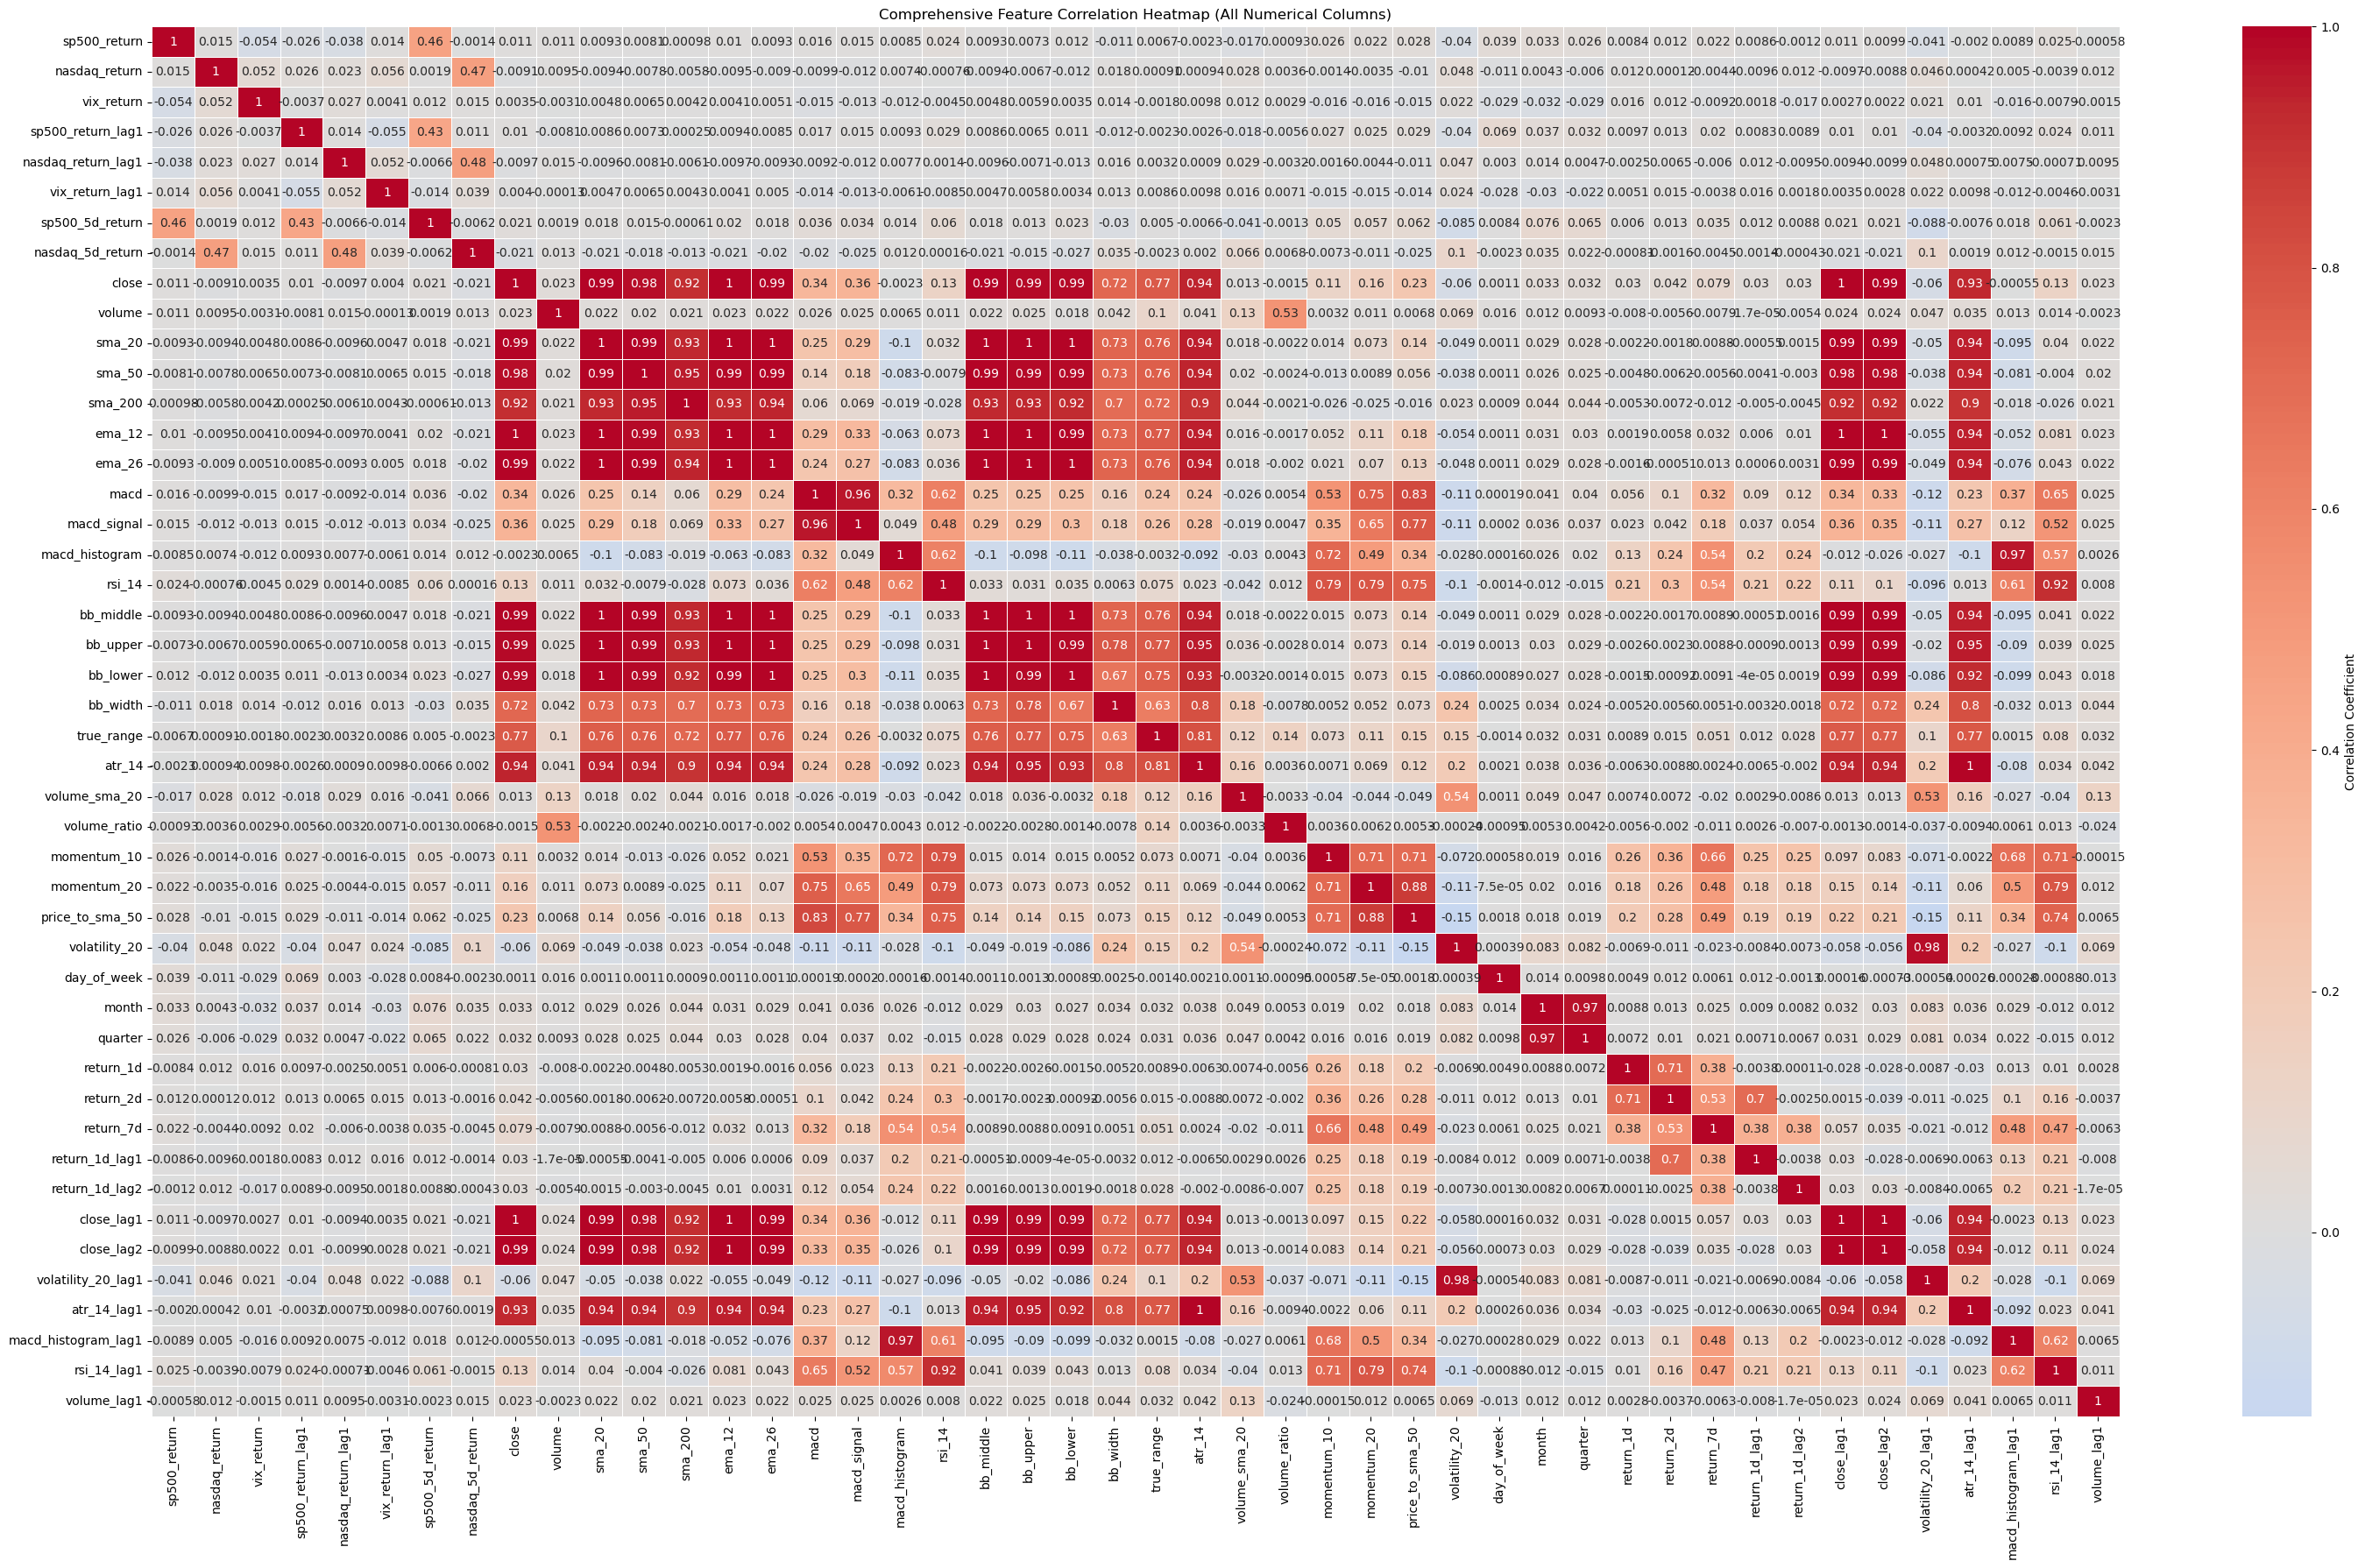

In [55]:
num_col = df_m_i.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = num_col.corr()

# Plot correlation heatmap
plt.figure(figsize=(30,18))
sns.heatmap(
# Select only numerical columns (exclude categorical or datetime)
    corr_matrix,
    cmap='coolwarm',
    annot=True, 
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Comprehensive Feature Correlation Heatmap (All Numerical Columns)')

plt.tight_layout()
plt.show()

### Observation of Findings

This was done to help narrow down vatiables that are not too correlated.

In [56]:
# Drop all correlated Features

df_m_ind = df_m_i.drop(['volume', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 
                        'macd_histogram_lag1', 'bb_middle', 'bb_upper', 'bb_lower', 'true_range', 
                        'volume_sma_20', 'momentum_20', 'volatility_20_lag1', 'return_7d', 
                        'atr_14_lag1', 'rsi_14'], axis=1)

In [57]:
df_m_ind.columns

Index(['date', 'market_regime', 'sp500_return', 'nasdaq_return', 'vix_return',
       'sp500_return_lag1', 'nasdaq_return_lag1', 'vix_return_lag1',
       'sp500_5d_return', 'nasdaq_5d_return', 'ticker', 'sector', 'close',
       'sma_20', 'macd_histogram', 'bb_width', 'atr_14', 'volume_ratio',
       'momentum_10', 'price_to_sma_50', 'volatility_20', 'trend_label',
       'day_of_week', 'month', 'quarter', 'return_1d', 'return_2d',
       'return_1d_lag1', 'return_1d_lag2', 'close_lag1', 'close_lag2',
       'rsi_14_lag1', 'volume_lag1'],
      dtype='object')

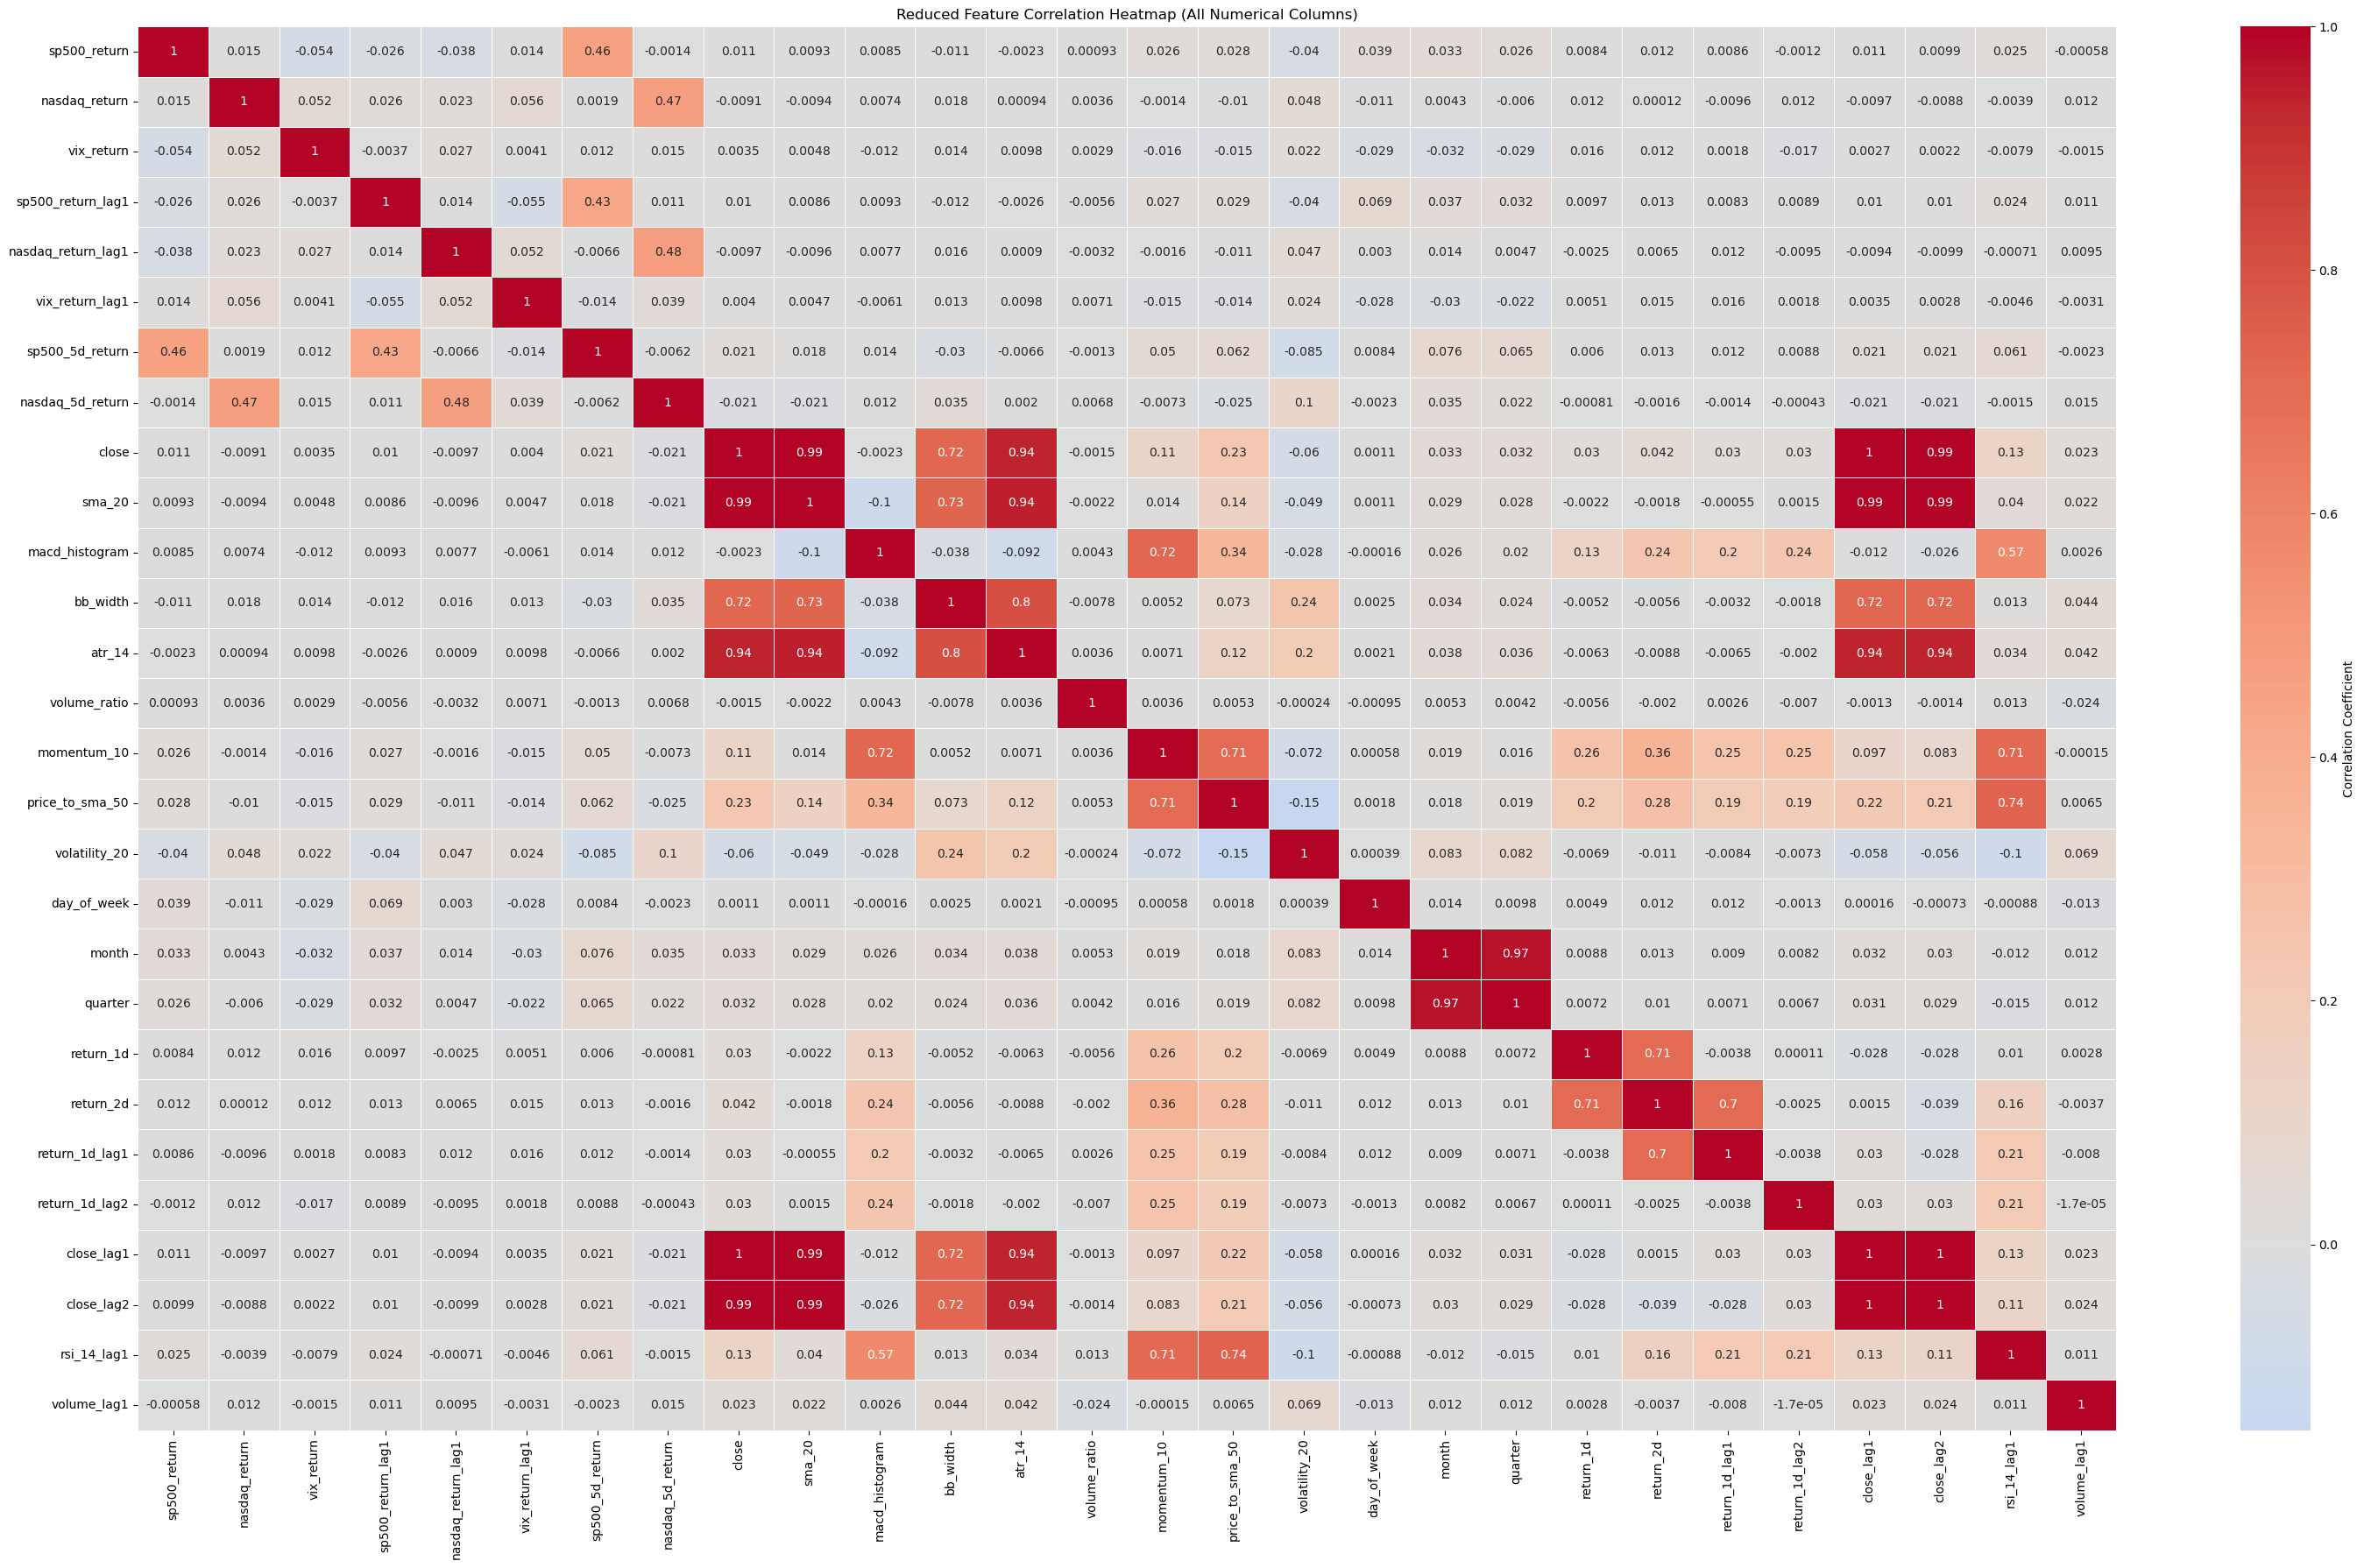

In [58]:
num_cols = df_m_ind.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr = num_cols.corr()

# Plot correlation heatmap
plt.figure(figsize=(30,18))
sns.heatmap(
# Select only numerical columns (exclude categorical or datetime)
    corr,
    cmap='coolwarm',
    annot=True, 
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Reduced Feature Correlation Heatmap (All Numerical Columns)')

plt.tight_layout()
plt.show()

### Observation of Findings

Strong multicollinearity exists among several features providing duplicate information, especially:

- close - close_lag1 (~0.99)

- sma_20 - sma_50 (~0.99)

- bb_width - volatility_20 (~0.80)

Moving averages are highly correlated, confirming they represent the same trend patterns.

Momentum indicators show moderate correlation, meaning they capture related but not identical behavior.

Lagged features correlate with their current values, which is expected, but using too many creates redundancy.

Market index returns show very low correlation with technical indicators, meaning they add independent macro-level signals.

In [59]:
df_ind = df_m_ind.drop(['sma_20', 'macd_histogram', 'close_lag2', 'return_1d_lag2', 
                        'return_2d', 'close_lag1', 'bb_width'], axis=1)

### Variance Inflation Factor to Check for Multicollinearity

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric features for VIF
X = df_ind.select_dtypes(include=['float64', 'int64']).dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data


,feature,VIF
0,sp500_return,1.390085
1,nasdaq_return,1.390939
2,vix_return,1.014192
3,sp500_return_lag1,1.358037
4,nasdaq_return_lag1,1.396546
5,vix_return_lag1,1.014215
6,sp500_5d_return,1.722243
7,nasdaq_5d_return,1.825535
8,close,71.756555
9,atr_14,66.177775


### Observation of Findings

Values above the common thresholds (VIF > 10) shows severe multicollinearity. This analysis showed that close, atr_14, volume_ratio, volatility_20, month, quarter, and rsi_14_lag1 had extremely high multicollinearity, meaning they were providing redundant information already captured by other features. Dropping them reduces feature overlap and stabilizes the model.

In [61]:
# Dropping variables with VIF above 10

df_clean = df_ind.drop(['close', 'atr_14', 'volume_ratio', 'volatility_20', 'month', 
                        'quarter', 'rsi_14_lag1'], axis=1)

In [62]:
# Select only numeric features for VIF
X = df_clean.select_dtypes(include=['float64', 'int64']).dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,feature,VIF
0,sp500_return,1.388698
1,nasdaq_return,1.389313
2,vix_return,1.011642
3,sp500_return_lag1,1.355193
4,nasdaq_return_lag1,1.395362
5,vix_return_lag1,1.011178
6,sp500_5d_return,1.704771
7,nasdaq_5d_return,1.815473
8,momentum_10,2.232053
9,price_to_sma_50,2.027728


In [63]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15505 entries, 0 to 15504
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                15505 non-null  datetime64[ns]
 1   market_regime       15505 non-null  object        
 2   sp500_return        15485 non-null  float64       
 3   nasdaq_return       15485 non-null  float64       
 4   vix_return          15485 non-null  float64       
 5   sp500_return_lag1   15465 non-null  float64       
 6   nasdaq_return_lag1  15465 non-null  float64       
 7   vix_return_lag1     15465 non-null  float64       
 8   sp500_5d_return     15405 non-null  float64       
 9   nasdaq_5d_return    15405 non-null  float64       
 10  ticker              15500 non-null  object        
 11  sector              15500 non-null  object        
 12  momentum_10         15500 non-null  float64       
 13  price_to_sma_50     15500 non-null  float64   

In [64]:
df_clean.isna().sum()

date                    0
market_regime           0
sp500_return           20
nasdaq_return          20
vix_return             20
sp500_return_lag1      40
nasdaq_return_lag1     40
vix_return_lag1        40
sp500_5d_return       100
nasdaq_5d_return      100
ticker                  5
sector                  5
momentum_10             5
price_to_sma_50         5
trend_label             5
day_of_week             5
return_1d               6
return_1d_lag1          7
volume_lag1             6
dtype: int64

In [65]:
# To handle missing data using ffill and bfill

# 1. To remove rows where ticker is missing
df_clean = df_clean[df_clean['ticker'].notna()].copy()

# 2. sort correctly
df_clean = df_clean.sort_values(['ticker', 'date'])

# 3. forward fill within each ticker
df_clean = (df_clean.groupby('ticker')
                     .apply(lambda x: x.ffill())
                     .reset_index(drop=True))
# 4. backward fill (optional)
df_clean = (df_clean.groupby('ticker')
                     .apply(lambda x: x.bfill())
                     .reset_index(drop=True))

C:\Users\estee\AppData\Local\Temp\ipykernel_38160\1568924758.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.ffill())
C:\Users\estee\AppData\Local\Temp\ipykernel_38160\1568924758.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.bfill())


In [66]:
df_clean.isna().sum()

date                  0
market_regime         0
sp500_return          0
nasdaq_return         0
vix_return            0
sp500_return_lag1     0
nasdaq_return_lag1    0
vix_return_lag1       0
sp500_5d_return       0
nasdaq_5d_return      0
ticker                0
sector                0
momentum_10           0
price_to_sma_50       0
trend_label           0
day_of_week           0
return_1d             0
return_1d_lag1        0
volume_lag1           0
dtype: int64

In [67]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                15500 non-null  datetime64[ns]
 1   market_regime       15500 non-null  object        
 2   sp500_return        15500 non-null  float64       
 3   nasdaq_return       15500 non-null  float64       
 4   vix_return          15500 non-null  float64       
 5   sp500_return_lag1   15500 non-null  float64       
 6   nasdaq_return_lag1  15500 non-null  float64       
 7   vix_return_lag1     15500 non-null  float64       
 8   sp500_5d_return     15500 non-null  float64       
 9   nasdaq_5d_return    15500 non-null  float64       
 10  ticker              15500 non-null  object        
 11  sector              15500 non-null  object        
 12  momentum_10         15500 non-null  float64       
 13  price_to_sma_50     15500 non-null  float64   

In [68]:
# safe reset index
df_clean = df_clean.reset_index(drop=True)

In [69]:
# To confirm missing values in target variable

df_clean['trend_label'].isna().sum()

0

### Data Splitting

In [70]:
# Define variables
target = 'trend_label'
features = [col for col in df_clean.columns if col not in ['ticker', 'date', target]]

# Temporal Data Split
df_split_date = df_clean['date'].quantile(0.7)
train_data = df_clean[df_clean['date'] <= df_split_date].copy()
test_data = df_clean[df_clean['date'] > df_split_date].copy()

print('Training Data Shape:', train_data.shape)
print('Testing Data Shape:', test_data.shape)
print('Split Date Threshold:', df_split_date)

Training Data Shape: (10860, 19)
Testing Data Shape: (4640, 19)
Split Date Threshold: 2023-02-01 00:00:00


In [71]:
# Record counts and date ranges
train_st, train_en = train_data['date'].min(), train_data['date'].max()
test_st, test_en = test_data['date'].min(), test_data['date'].max()

print(f"Train period: {train_st.date()} - {test_en.date()}  ({len(train_data)} records)")
print(f"Test period:  {test_start.date()} - {test_end.date()}  ({len(test_data)} records)")

# Class distribution in train and test
print("\nTrain class distribution:")
print(train_data['trend_label'].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(test_data['trend_label'].value_counts(normalize=True).round(3))

Train period: 2021-01-04 - 2023-12-22  (10860 records)
Test period:  2023-02-02 - 2023-12-22  (4640 records)

Train class distribution:
trend_label
Uptrend      0.352
Downtrend    0.338
Sideways     0.310
Name: proportion, dtype: float64

Test class distribution:
trend_label
Uptrend      0.368
Sideways     0.340
Downtrend    0.292
Name: proportion, dtype: float64


In [72]:
# Confirmation of class balance

# Train Imbalance
train_count = (train_data['trend_label'].value_counts())

train_imb_ratio = train_count.max() / train_count.min()
train_imb_ratio

1.1364041604754829

In [73]:
# Test Imbalance
test_count = (test_data['trend_label'].value_counts())

test_imb_ratio = test_count.max() / test_count.min()
test_imb_ratio

1.260709010339734

In [74]:
# Encode Categorical Variables
s_enc = LabelEncoder()
train_data['sector'] = s_enc.fit_transform(train_data['sector'])
test_data['sector'] = s_enc.transform(test_data['sector'])

m_enc = LabelEncoder()
train_data['market_regime'] = m_enc.fit_transform(train_data['market_regime'])
test_data['market_regime'] = m_enc.transform(test_data['market_regime'])

t_enc = LabelEncoder()
train_data['trend_label'] = t_enc.fit_transform(train_data['trend_label'])
test_data['trend_label'] = t_enc.transform(test_data['trend_label'])

In [75]:
# Scale Numerical variables

# Define numerical columns
number_cols = df_clean.select_dtypes(include=['number', 'float']).columns

# Initialize RobustScaler
r_scaler = RobustScaler()
train_data[number_cols] = r_scaler.fit_transform(train_data[number_cols])
test_data[number_cols] = r_scaler.transform(test_data[number_cols])

In [76]:
# Data Splitting
train_X = train_data[features]
train_y = train_data[target]
                   
test_X = test_data[features]
test_y = test_data[target]

# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
train_X_res, train_y_res = smote.fit_resample(train_X, train_y)

### Model Training

In [77]:
# Build Logistic Regression
l_model = LogisticRegression(max_iter=1000)
l_model.fit(train_X_res, train_y_res)

pred_y = l_model.predict(test_X)

# Model Evaluation
print("Accuracy:", accuracy_score(test_y, pred_y))
print("\nLogistic Regression Classification Report:\n", classification_report(test_y, pred_y, target_names=t_enc.classes_))

Accuracy: 0.3137931034482759

Logistic Regression Classification Report:
               precision    recall  f1-score   support

   Downtrend       0.26      0.22      0.24      1354
    Sideways       0.33      0.43      0.37      1579
     Uptrend       0.33      0.29      0.31      1707

    accuracy                           0.31      4640
   macro avg       0.31      0.31      0.31      4640
weighted avg       0.31      0.31      0.31      4640



### Observation of Findings

The Logistic Regression model achieves 31% accuracy, which is expected given the multi-class (3-class) setup and the limited linear separability of financial time-series data. The model performs best on the Sideways class (F1 = 0.37), which is the largest and most stable class, while Uptrend and Downtrend remain harder to classify (F1 = 0.31 and 0.24). This indicates that even after feature cleaning, linear models struggle to capture the non-linear patterns in market movements, confirming the need for more flexible models like Random Forest.

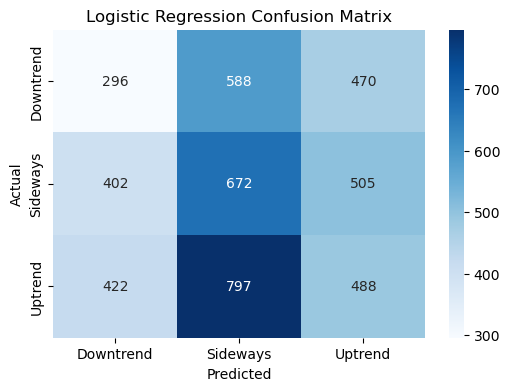

In [78]:
cm = confusion_matrix(test_y, pred_y)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_enc.classes_, yticklabels=t_enc.classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

The confusion matrix shows that the model predicts Sideways most frequently, causing many Downtrend and Uptrend cases to be misclassified as Sideways. This pattern reflects the model’s tendency to default to the majority/most stable class, indicating that Logistic Regression struggles to separate the three trend classes and cannot capture the non-linear structure of price movements.

In [79]:
# Build Random Forest Model
ran_for = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=None, random_state=42)

ran_for.fit(train_X_res, train_y_res)
pred_y_rf = ran_for.predict(test_X)

# Model Evaluation
print('\nRandom Forest Classification Report:\n', classification_report(test_y, pred_y_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.27      0.29      1354
           1       0.38      0.45      0.41      1579
           2       0.38      0.35      0.36      1707

    accuracy                           0.36      4640
   macro avg       0.35      0.36      0.35      4640
weighted avg       0.36      0.36      0.36      4640



### Observation of Findings

The Random Forest model improves overall accuracy to 36%, outperforming Logistic Regression (31%) and showing better class balance, especially for the Sideways class (F1 = 0.41). The model also captures more non-linear patterns, giving noticeable gains in recall and F1 across all classes, but the relatively modest improvement indicates that market trend prediction remains highly noisy and challenging, and further tuning or additional features may be needed.

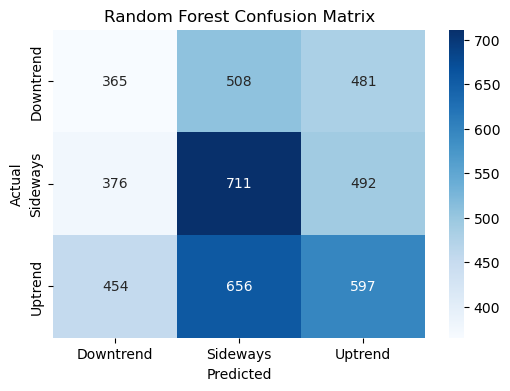

In [80]:
cm = confusion_matrix(test_y, pred_y_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_enc.classes_, yticklabels=t_enc.classes_)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

The confusion matrix shows that Random Forest still predicts Sideways most frequently, but does so more accurately than Logistic Regression, correctly identifying 711 Sideways cases. Misclassifications into Sideways remain common, yet the model shows improved balance - correctly predicting more Downtrend and Uptrend cases compared to Logistic Regression. This indicates that Random Forest captures more non-linear trend patterns even though class separation is still challenging.

### Feature Importance

In [81]:
importance = ran_for.feature_importances_
feat_names = train_X_res.columns

fi_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

fi_df

,feature,importance
11,price_to_sma_50,0.105911
10,momentum_10,0.101676
13,return_1d,0.100045
14,return_1d_lag1,0.099454
15,volume_lag1,0.096789
8,nasdaq_5d_return,0.054545
7,sp500_5d_return,0.053684
6,vix_return_lag1,0.052524
4,sp500_return_lag1,0.051755
1,sp500_return,0.051564


### Observation of Findings

The feature-importance results show that only a few features (such as price_to_sma_50, momentum_10, return_1d, return_1d_lag1, and volume_lag1) contribute meaningfully to the model, all having importance scores above 0.05. Features below the 0.05 threshold (e.g., sector, day_of_week, market_regime) add minimal predictive value and were appropriately removed, leaving a more compact and more relevant feature set that focuses on momentum, relative price position, and short-term returns—patterns that the model relies on most for trend classification.

<Figure size 1000x600 with 0 Axes>

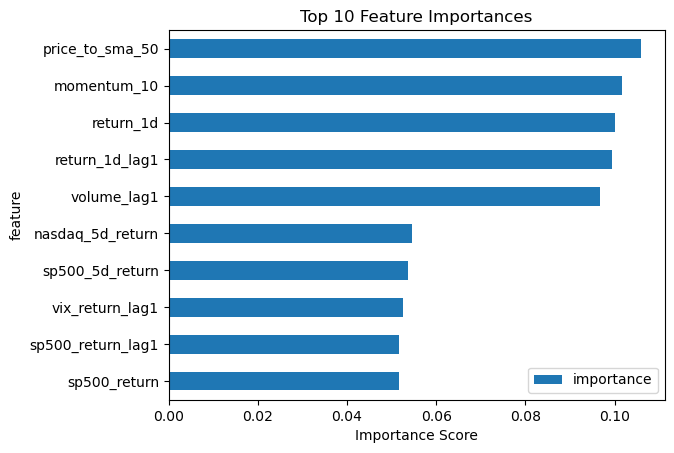

In [82]:
# Graphical Representation of Feature Importance

plt.figure(figsize=(10,6))
fi_df.head(10).plot(kind='barh', x='feature', y='importance')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")

plt.show()

### Observation of Findings

The most influential features are price_to_sma_50, momentum_10, return_1d, return_1d_lag1, and volume_lag1, indicating that the model relies primarily on short-term momentum, lagged returns, and relative price position to predict market trends. Lower-ranked features such as index-based returns (S&P 500, NASDAQ, VIX) still contribute but play a smaller role, showing that macro-level movements support the prediction, while technical and momentum signals drive the majority of model decisions.

In [83]:
# Drop features less than 5% from fi_df

df_cleaned = df_clean.drop(['sector', 'market_regime', 'day_of_week'], axis=1)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                15500 non-null  datetime64[ns]
 1   sp500_return        15500 non-null  float64       
 2   nasdaq_return       15500 non-null  float64       
 3   vix_return          15500 non-null  float64       
 4   sp500_return_lag1   15500 non-null  float64       
 5   nasdaq_return_lag1  15500 non-null  float64       
 6   vix_return_lag1     15500 non-null  float64       
 7   sp500_5d_return     15500 non-null  float64       
 8   nasdaq_5d_return    15500 non-null  float64       
 9   ticker              15500 non-null  object        
 10  momentum_10         15500 non-null  float64       
 11  price_to_sma_50     15500 non-null  float64       
 12  trend_label         15500 non-null  object        
 13  return_1d           15500 non-null  float64   

### Model Re-training

In [84]:
# Define variables
target_fi = 'trend_label'
features_fi = [col for col in df_cleaned.columns if col not in ['ticker', 'date', target_fi]]

# Temporal Data Split
df_fi_split_date = df_cleaned['date'].quantile(0.7)
fi_train_data = df_cleaned[df_cleaned['date'] <= df_fi_split_date].copy()
fi_test_data = df_cleaned[df_cleaned['date'] > df_fi_split_date].copy()

# Encode target variable
t_encd = LabelEncoder()
fi_train_data['trend_label'] = t_encd.fit_transform(fi_train_data['trend_label'])
fi_test_data['trend_label'] = t_encd.transform(fi_test_data['trend_label'])

# Scale Numerical variables

# Define numerical columns
numerical_col = df_cleaned.select_dtypes(include=['number', 'float']).columns

# Initialize RobustScaler
ro_scaler = RobustScaler()
fi_train_data[numerical_col] = ro_scaler.fit_transform(fi_train_data[numerical_col])
fi_test_data[numerical_col] = ro_scaler.transform(fi_test_data[numerical_col])

# Data Splitting
fi_train_X = fi_train_data[features_fi]
fi_train_y = fi_train_data[target_fi]
                   
fi_test_X = fi_test_data[features_fi]
fi_test_y = fi_test_data[target_fi]

# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
fi_train_X_res, fi_train_y_res = smote.fit_resample(fi_train_X, fi_train_y)

In [85]:
# Build Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=None, random_state=42)

rf_model.fit(fi_train_X_res, fi_train_y_res)
fi_pred_base = rf_model.predict(fi_test_X)

# Model Evaluation
print('\nRandom Forest (FI) Classification Report:\n', classification_report(fi_test_y, fi_pred_base))


Random Forest (FI) Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.26      0.28      1354
           1       0.33      0.36      0.35      1579
           2       0.36      0.38      0.37      1707

    accuracy                           0.34      4640
   macro avg       0.33      0.33      0.33      4640
weighted avg       0.34      0.34      0.34      4640



### Observation of Findings

After keeping only the most important features, model accuracy is 34%, slightly lower than the full-feature version (36%), but the performance remains stable across all classes. The model still predicts Uptrend and Sideways better than Downtrend, showing that removing low-importance and redundant features reduces noise without significantly hurting predictive performance. This confirms that the final feature set is lean, non-redundant, and still retains the core signal the model relies on.

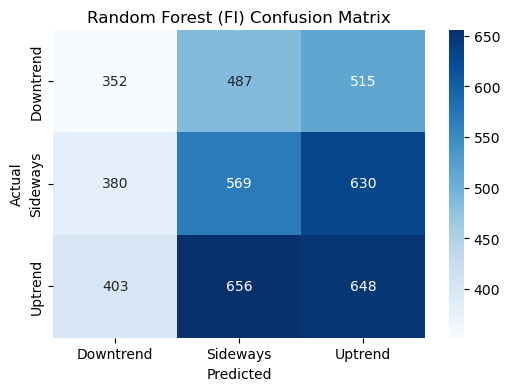

In [86]:
cm = confusion_matrix(fi_test_y, fi_pred_base)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_encd.classes_, yticklabels=t_encd.classes_)
plt.title("Random Forest (FI) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findigs

After reducing the feature set using feature importance, the model still predicts Sideways most frequently, but now shows a noticeable shift with more Uptrend cases (648) being correctly identified than before. However, confusion between Sideways and Uptrend increases, indicating that with fewer features the model tends to blend these two classes more often. Overall, the confusion matrix shows that the simplified feature set maintains reasonable class balance but slightly reduces the model's ability to separate Sideways vs Uptrend movements.

### Model tuning

In [87]:
from sklearn.model_selection import RandomizedSearchCV

para_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 40, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rs = RandomizedSearchCV(
    rf,
    param_distributions=para_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rs.fit(fi_train_X_res, fi_train_y_res)
best_model = rs.best_estimator_

In [88]:
fi_pred_y = best_model.predict(fi_test_X)

print("Best Parameters:", rs.best_params_)
print("Best Estimator:", rs.best_estimator_)
print("\nTuned Random Forest (FI) Classification Report:\n")
print(classification_report(fi_test_y, fi_pred_y))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
Best Estimator: RandomForestClassifier(max_depth=40, max_features='log2', min_samples_split=5,
                       n_estimators=200, random_state=42)

Tuned Random Forest (FI) Classification Report:

              precision    recall  f1-score   support

           0       0.31      0.26      0.28      1354
           1       0.35      0.37      0.36      1579
           2       0.37      0.39      0.38      1707

    accuracy                           0.35      4640
   macro avg       0.34      0.34      0.34      4640
weighted avg       0.35      0.35      0.35      4640



### Observation of Findings

Hyperparameter tuning slightly improves model balance, increasing recall and F1 for both Sideways (1) and Uptrend (2), while maintaining overall accuracy at 35%. The tuned model captures non-linear patterns more effectively than the baseline FI model, with the strongest gains in class 2 (Uptrend), showing that tuning helps the model distinguish upward movements more confidently. However, improvements remain incremental, indicating that market trend prediction is inherently noisy and may require additional feature engineering or alternative models for larger performance gains.

### Confusion Matrix

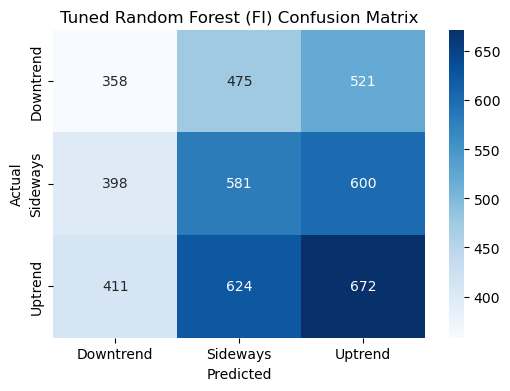

In [89]:
cm = confusion_matrix(fi_test_y, fi_pred_y)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_encd.classes_, yticklabels=t_encd.classes_)
plt.title("Tuned Random Forest (FI) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

The tuned model shows a clearer separation between Uptrend and Sideways, correctly identifying 672 Uptrend cases - the highest so far across all models. However, misclassifications between these two classes remain common, indicating overlapping patterns in the features. Overall, tuning improved the model’s ability to detect Uptrend movements while maintaining similar performance on Downtrend and Sideways classes.

<Figure size 1000x600 with 0 Axes>

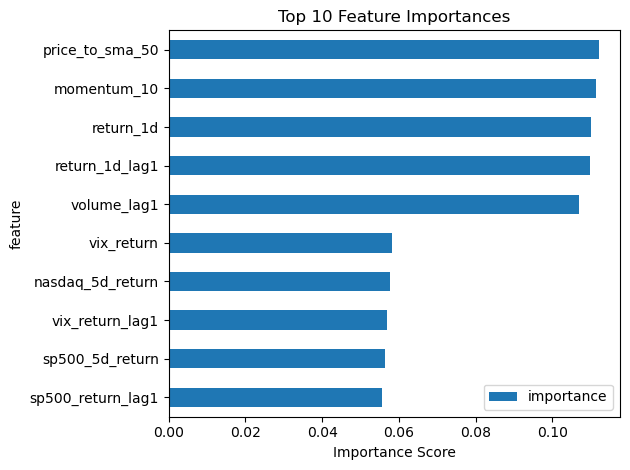

In [90]:
# Final Feature Importance

importance = best_model.feature_importances_
feat_names = fi_test_X.columns

fi_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Graphical Representation of Feature Importance

plt.figure(figsize=(10,6))
fi_df.head(10).plot(kind='barh', x='feature', y='importance')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [96]:
# Save random forest on feature importance

best_model = rs.best_estimator_
joblib.dump(best_model, "../models/Tuned_RandomForest_Model.pkl", compress=3)

['../models/Tuned_RandomForest_Model.pkl']

### SHAP Analysis

In [92]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [93]:
print(best_model.classes_)
print(t_encd.classes_)


[0 1 2]
['Downtrend' 'Sideways' 'Uptrend']


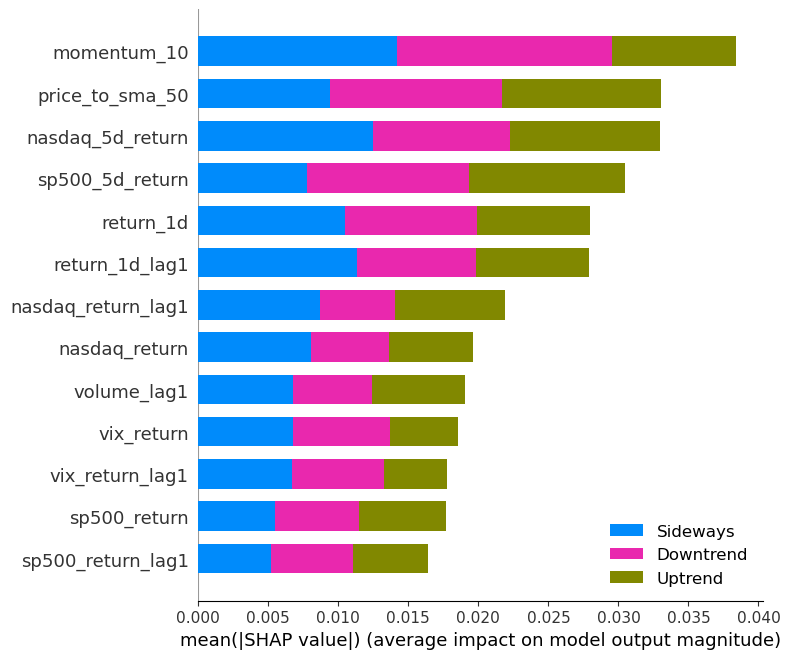

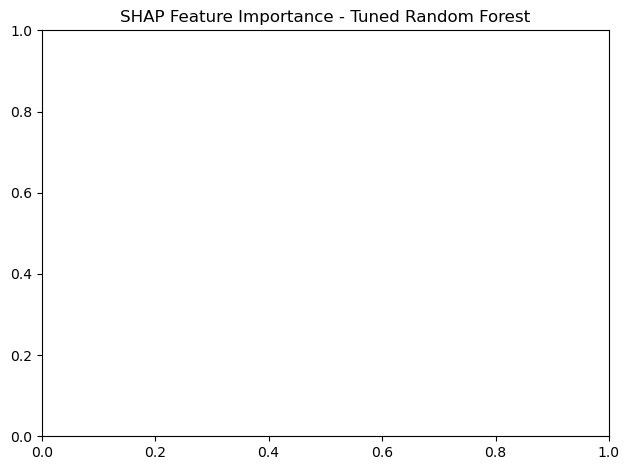

In [94]:
import shap

class_names = t_encd.inverse_transform(best_model.classes_)
best_model = rs.best_estimator_
X_shap = fi_test_X.copy()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", class_names=class_names)
plt.title("SHAP Feature Importance - Tuned Random Forest")

plt.tight_layout()

### Observation of Findings

Sideways (Class 0)

Sideways predictions receive their strongest contributions from momentum_10, nasdaq_5d_return, and return_1d_lag1.
These features reflect mild or mixed recent market signals, which help the model identify periods where price movement is neutral rather than directional.

Downtrend (Class 1)

Downtrend predictions are driven mainly by momentum_10, price_to_sma_50, and sp500_5d_return.
This means the model uses decreasing momentum, weakening S&P 500 performance, and price positions below the SMA to classify downward movement.

Uptrend (Class 2)

Uptrend predictions rely most heavily on price_to_sma_50, nasdaq_5d_return, and sp500_5d_return.
These indicators show strong upward pressure, both from the broader market (NASDAQ, S&P 500) and from the stock’s position relative to its moving average.

### Save Final Feature_Engineered Dataset

In [95]:
df_cleaned.to_csv('../data/final_dataset.csv', index=False)